# PRT Assignment — Python, EDA, Machine Learning & Time Series Analysis

This notebook analyses **`PRT_Python_Time_Series_Dataset.csv`** (daily retail transactions, Jan 2023 – Dec 2025).

**Columns:** `Date`, `Store`, `Product`, `Category`, `Region`, `Units_Sold`, `Price`, `Discount`, `Promotion`, `Customer_Age`, `Rating`, `Revenue`

| Section | Content |
|---|---|
| 1 | Question 1 — Data Cleaning & Analysis (Pandas) |
| 2 | Question 2 — Exploratory Data Analysis |
| 3 | Question 3 — Machine Learning (Random Forest Regressor) |
| 4 | Question 4 — Time Series Analysis & Forecasting |


In [1]:
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Question 1 — Python & Pandas: Data Cleaning and Analysis

1. Display the first 10 records and the dataset shape
2. Check data types and identify missing values
3. Handle missing values in `Customer_Age` and `Rating`
4. Total revenue generated by each `Category`
5. Top 3 products based on total `Revenue`
6. Average `Units_Sold` for each `Region`


In [2]:
DATA_PATH = "PRT_Python_Time_Series_Dataset.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head(10)

Dataset shape: 1000 rows x 12 columns


,Date,Store,Product,Category,Region,Units_Sold,Price,Discount,Promotion,Customer_Age,Rating,Revenue
0,2023-01-01,Store_D,Smartwatch,Accessories,South,12,150,0.29,No,60.0,4.5,1280.64
1,2023-01-01,Store_A,Smartwatch,Accessories,West,1,150,0.23,Yes,42.0,4.8,138.89
2,2023-01-02,Store_C,Tablet,Electronics,East,13,350,0.28,No,19.0,4.1,3289.52
3,2023-01-02,Store_C,Smartwatch,Accessories,North,9,150,0.29,No,25.0,3.8,962.46
4,2023-01-04,Store_E,Tablet,Electronics,North,5,350,0.12,No,46.0,3.5,1552.71
5,2023-01-04,Store_C,Phone,Electronics,East,12,500,0.12,No,21.0,3.2,5323.56
6,2023-01-05,Store_B,Laptop,Electronics,West,12,700,0.20,No,43.0,3.2,6789.27
7,2023-01-05,Store_D,Phone,Electronics,East,11,500,0.20,No,23.0,2.9,4445.36
8,2023-01-06,Store_A,Tablet,Electronics,North,8,350,0.09,No,18.0,5.0,2579.50
9,2023-01-07,Store_B,Phone,Electronics,South,4,500,0.27,Yes,57.0,4.3,1777.26


In [3]:
print("Data types:")
print(df.dtypes)

missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values")

Data types:
Date            datetime64[ns]
Store                   object
Product                 object
Category                object
Region                  object
Units_Sold               int64
Price                    int64
Discount               float64
Promotion               object
Customer_Age           float64
Rating                 float64
Revenue                float64
dtype: object

Missing values per column:
Customer_Age    30
Rating          20
dtype: int64


In [4]:
age_median = df["Customer_Age"].median()
rating_median = df["Rating"].median()

print(f"Imputing Customer_Age with median: {age_median}")
print(f"Imputing Rating with median:      {rating_median}")

df["Customer_Age"] = df["Customer_Age"].fillna(age_median)
df["Rating"] = df["Rating"].fillna(rating_median)

print("\nRemaining missing values after imputation:")
print(df[["Customer_Age", "Rating"]].isnull().sum())

Imputing Customer_Age with median: 41.0
Imputing Rating with median:      3.7

Remaining missing values after imputation:
Customer_Age    0
Rating          0
dtype: int64


In [5]:
revenue_by_category = (
    df.groupby("Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .to_frame("Total_Revenue")
)
revenue_by_category

,Total_Revenue
Category,
Electronics,2276433.85
Accessories,334687.97


In [6]:
top_products = (
    df.groupby("Product")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(3)
      .to_frame("Total_Revenue")
)
top_products

,Total_Revenue
Product,
Laptop,1048998.24
Phone,782175.88
Tablet,445259.73


In [7]:
avg_units_by_region = (
    df.groupby("Region")["Units_Sold"]
      .mean()
      .round(2)
      .sort_values(ascending=False)
      .to_frame("Avg_Units_Sold")
)
avg_units_by_region

,Avg_Units_Sold
Region,
East,8.05
North,8.03
West,7.84
South,7.83


## Question 2 — Exploratory Data Analysis

1. Total and average `Revenue` for each `Store`
2. Average revenue when `Promotion` = Yes vs No
3. Product with the highest average `Rating`
4. Month with the highest total revenue
5. Visualisation: Revenue by Product
6. Correlation matrix and variables most strongly correlated with `Revenue`


In [8]:
store_summary = (
    df.groupby("Store")["Revenue"]
      .agg(Total_Revenue="sum", Average_Revenue="mean")
      .round(2)
      .sort_values("Total_Revenue", ascending=False)
)
store_summary

,Total_Revenue,Average_Revenue
Store,,
Store_A,605561.51,2777.81
Store_E,560753.19,2645.06
Store_B,492639.14,2662.91
Store_C,477234.56,2350.91
Store_D,474933.42,2609.52


In [9]:
promo_comparison = (
    df.groupby("Promotion")["Revenue"]
      .mean()
      .round(2)
      .to_frame("Average_Revenue")
)

diff = promo_comparison.loc["Yes", "Average_Revenue"] - promo_comparison.loc["No", "Average_Revenue"]
print(f"Average revenue difference (Yes - No): {diff:,.2f}")
promo_comparison

Average revenue difference (Yes - No): 414.05


,Average_Revenue
Promotion,
No,2467.86
Yes,2881.91


In [10]:
avg_rating = df.groupby("Product")["Rating"].mean().sort_values(ascending=False)

print(f"Highest rated product: {avg_rating.idxmax()} (average rating = {avg_rating.max():.2f})")
avg_rating.round(2).to_frame("Avg_Rating")

Highest rated product: Smartwatch (average rating = 3.88)


,Avg_Rating
Product,
Smartwatch,3.88
Laptop,3.75
Phone,3.71
Headphones,3.66
Tablet,3.60


In [11]:
df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_totals = df.groupby("Month")["Revenue"].sum()

print(f"Month with highest total revenue: {monthly_totals.idxmax()} ({monthly_totals.max():,.2f})")
monthly_totals.sort_values(ascending=False).head(10).to_frame("Total_Revenue")

Month with highest total revenue: 2024-05 (118,036.48)

,Total_Revenue
Month,
2024-05,118036.48
2025-03,109442.29
2025-04,105042.18
2025-05,97533.66
2025-01,93697.69
2023-01,89244.02
2024-07,88852.63
2023-08,87930.43
2023-02,87716.17


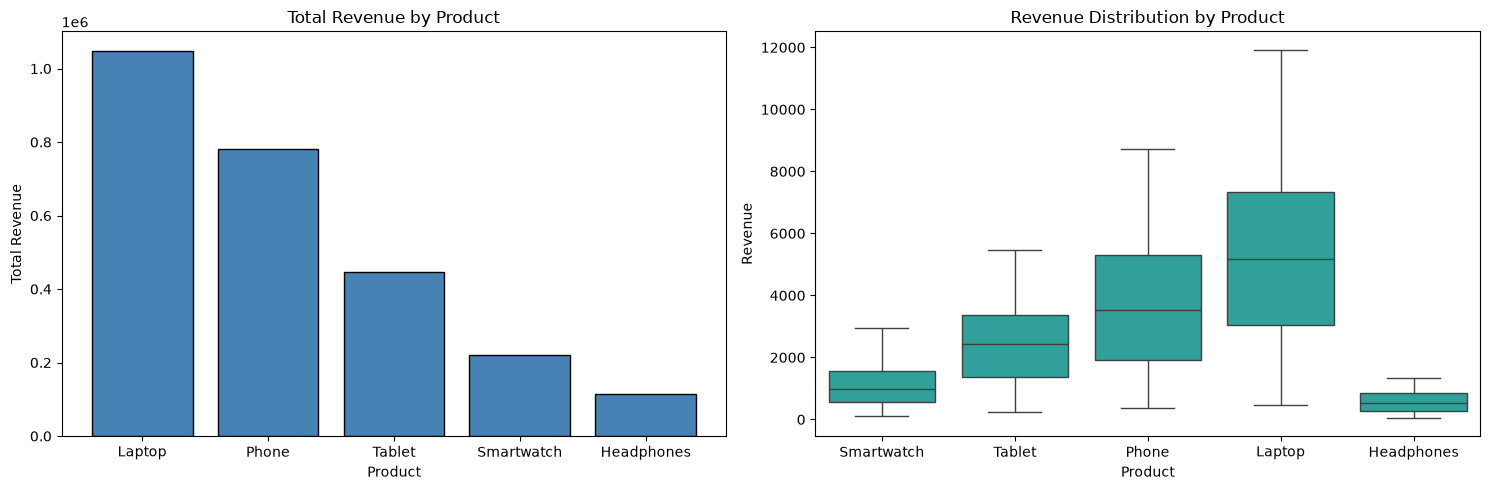

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

product_revenue = df.groupby("Product")["Revenue"].sum().sort_values(ascending=False)
axes[0].bar(product_revenue.index, product_revenue.values, color="steelblue", edgecolor="black")
axes[0].set_title("Total Revenue by Product")
axes[0].set_xlabel("Product")
axes[0].set_ylabel("Total Revenue")

sns.boxplot(data=df, x="Product", y="Revenue", ax=axes[1], color="lightseagreen")
axes[1].set_title("Revenue Distribution by Product")
axes[1].set_xlabel("Product")
axes[1].set_ylabel("Revenue")

plt.tight_layout()
plt.show()

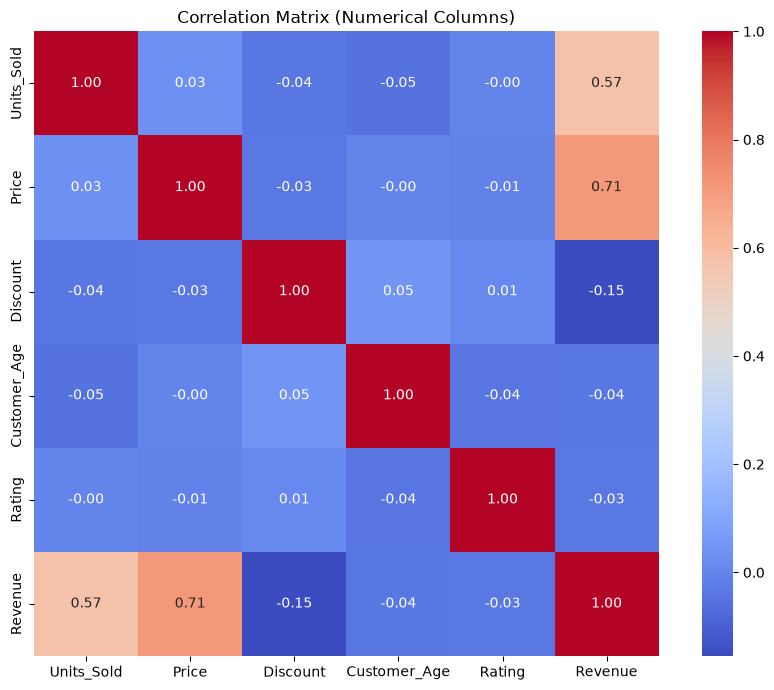

Variables most strongly correlated with Revenue:
Price           0.715
Units_Sold      0.574
Rating         -0.035
Customer_Age   -0.041
Discount       -0.154
Name: Revenue, dtype: float64


In [13]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix (Numerical Columns)")
plt.tight_layout()
plt.show()

print("Variables most strongly correlated with Revenue:")
print(corr_matrix["Revenue"].drop("Revenue").sort_values(ascending=False).round(3))

## Question 3 — Machine Learning: Predicting Revenue

1. Select features and target (`Revenue`)
2. Preprocess: one-hot encode categorical variables
3. Split into 80% train / 20% test
4. Train a **Random Forest Regressor**
5. Predict revenue on the test set
6. Evaluate: MAE, MSE, RMSE, R2 Score
7. Feature importance — top 5 features


In [14]:
FEATURES = ["Store", "Product", "Category", "Region", "Units_Sold",
            "Price", "Discount", "Promotion", "Customer_Age", "Rating"]
TARGET = "Revenue"

X = pd.get_dummies(
    df[FEATURES],
    columns=["Store", "Product", "Category", "Region", "Promotion"],
    drop_first=True,
)
y = df[TARGET]

print(f"Encoded feature matrix shape: {X.shape}")
X.head()

Encoded feature matrix shape: (1000, 18)


,Units_Sold,Price,Discount,Customer_Age,Rating,Store_Store_B,Store_Store_C,Store_Store_D,Store_Store_E,Product_Laptop,Product_Phone,Product_Smartwatch,Product_Tablet,Category_Electronics,Region_North,Region_South,Region_West,Promotion_Yes
0,12,150,0.29,60.0,4.5,False,False,True,False,False,False,True,False,False,False,True,False,False
1,1,150,0.23,42.0,4.8,False,False,False,False,False,False,True,False,False,False,False,True,True
2,13,350,0.28,19.0,4.1,False,True,False,False,False,False,False,True,True,False,False,False,False
3,9,150,0.29,25.0,3.8,False,True,False,False,False,False,True,False,False,True,False,False,False
4,5,350,0.12,46.0,3.5,False,False,False,True,False,False,False,True,True,True,False,False,False


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training samples: {len(X_train)} ({len(X_train) / len(X):.0%})")
print(f"Testing samples : {len(X_test)} ({len(X_test) / len(X):.0%})")

Training samples: 800 (80%)
Testing samples : 200 (20%)


In [16]:
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Model trained — predictions generated for the test set.")

Model trained — predictions generated for the test set.


In [17]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

evaluation = pd.DataFrame(
    {"Metric": ["MAE", "MSE", "RMSE", "R2 Score"], "Value": [mae, mse, rmse, r2]}
).set_index("Metric")
evaluation

,Value
Metric,
MAE,268.651372
MSE,182326.793740
RMSE,426.997417
R2 Score,0.975078


Top 5 important features:
Units_Sold              0.4409
Price                   0.4340
Discount                0.0250
Category_Electronics    0.0218
Product_Tablet          0.0179
dtype: float64


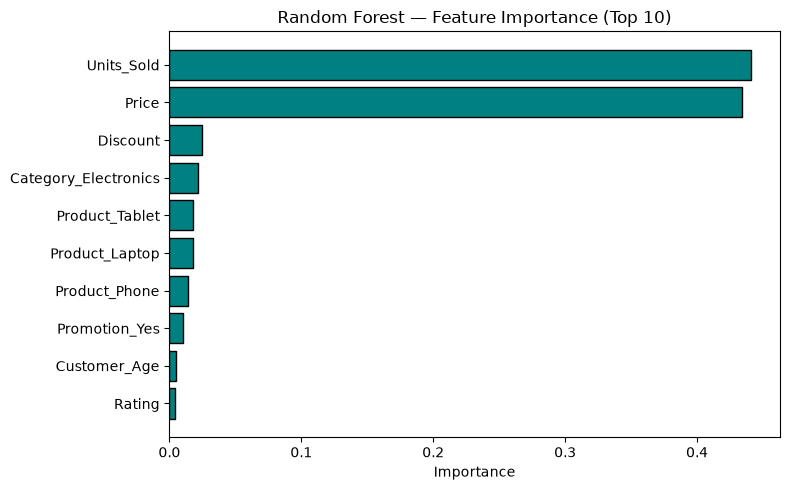

In [18]:
importances = (
    pd.Series(rf_model.feature_importances_, index=X.columns)
      .sort_values(ascending=False)
)

print("Top 5 important features:")
print(importances.head(5).round(4))

top10 = importances.head(10)
plt.figure(figsize=(8, 5))
plt.barh(top10.index[::-1], top10.values[::-1], color="teal", edgecolor="black")
plt.title("Random Forest — Feature Importance (Top 10)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Question 4 — Time Series Analysis

1. Convert `Date` to datetime and set it as the index
2. Resample to monthly total revenue
3. Plot monthly revenue as a time-series line chart
4. Calculate the 3-month moving average of revenue
5. Identify months with the highest and lowest revenue
6. Trend / seasonality analysis
7. Forecast revenue for the next 3 months


In [19]:
ts = df.copy()
ts["Date"] = pd.to_datetime(ts["Date"])
ts = ts.set_index("Date").sort_index()

print(f"Index: {type(ts.index).__name__} | Range: {ts.index.min().date()} -> {ts.index.max().date()}")

Index: DatetimeIndex | Range: 2023-01-01 -> 2025-12-31


In [20]:
monthly_revenue = ts["Revenue"].resample("MS").sum().round(2)

print(f"Months covered: {len(monthly_revenue)}")
monthly_revenue.head(12).to_frame("Monthly_Total_Revenue")

Months covered: 36


,Monthly_Total_Revenue
Date,
2023-01-01,89244.02
2023-02-01,87716.17
2023-03-01,76330.20
2023-04-01,62483.00
2023-05-01,66431.43
2023-06-01,51262.37
2023-07-01,52447.78
2023-08-01,87930.43
2023-09-01,62647.24


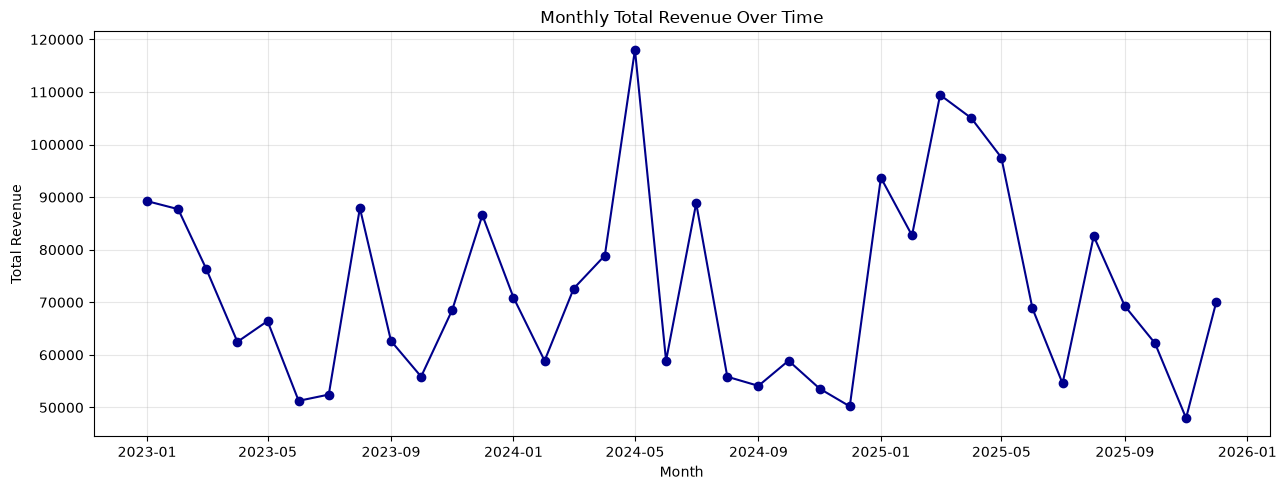

In [21]:
plt.figure(figsize=(13, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", color="darkblue")
plt.title("Monthly Total Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

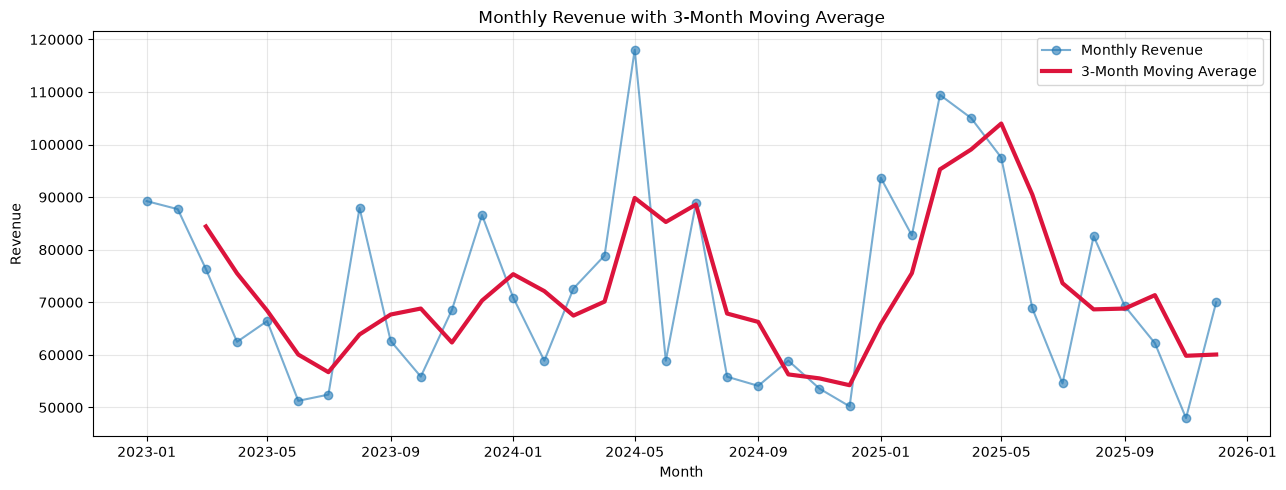

,Moving_Avg_3M
Date,
2023-03-01,84430.130000
2023-04-01,75509.790000
2023-05-01,68414.876667
2023-06-01,60058.933333
2023-07-01,56713.860000
2023-08-01,63880.193333
2023-09-01,67675.150000
2023-10-01,68814.280000
2023-11-01,62355.166667


In [22]:
moving_avg_3m = monthly_revenue.rolling(window=3).mean()

plt.figure(figsize=(13, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", alpha=0.6, label="Monthly Revenue")
plt.plot(moving_avg_3m.index, moving_avg_3m.values, linewidth=3, color="crimson", label="3-Month Moving Average")
plt.title("Monthly Revenue with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

moving_avg_3m.dropna().to_frame("Moving_Avg_3M")

In [23]:
highest_month = monthly_revenue.idxmax()
lowest_month = monthly_revenue.idxmin()

print(f"Highest revenue month: {highest_month.strftime('%B %Y')} -> {monthly_revenue.max():,.2f}")
print(f"Lowest  revenue month: {lowest_month.strftime('%B %Y')} -> {monthly_revenue.min():,.2f}")

Highest revenue month: May 2024 -> 118,036.48
Lowest  revenue month: November 2025 -> 47,979.05


Overall linear trend: INCREASING (~31.01 change in revenue per month)


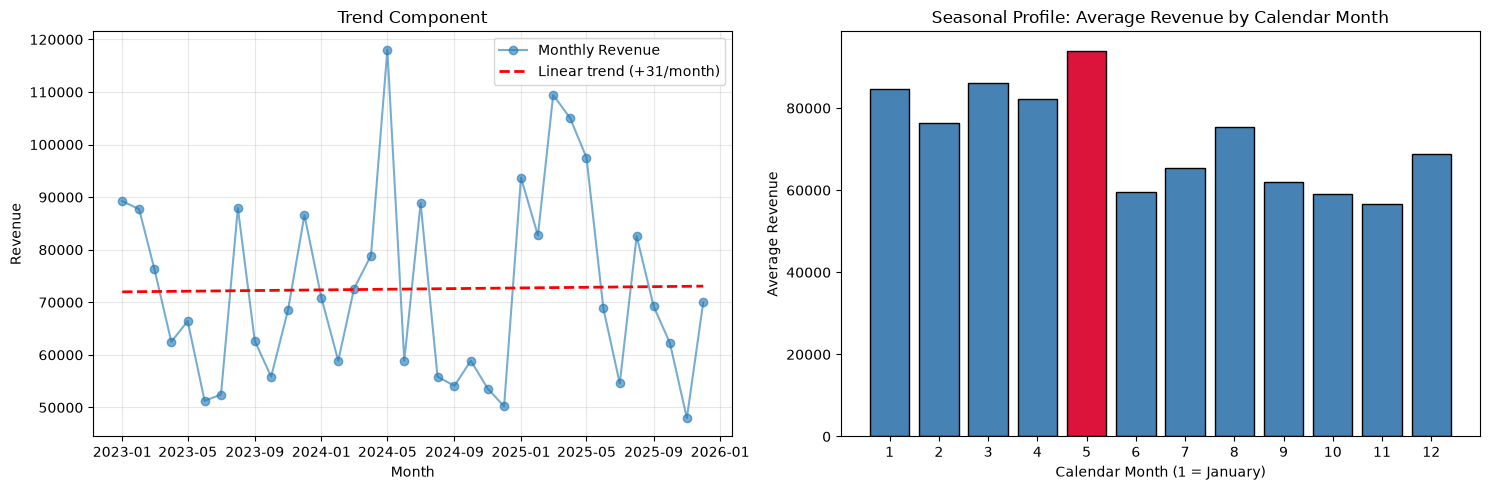

Strongest calendar month on average: 5 | Weakest: 11


In [24]:
x_idx = np.arange(len(monthly_revenue))
slope, intercept = np.polyfit(x_idx, monthly_revenue.values, 1)
direction = "INCREASING" if slope > 0 else "DECREASING"
print(f"Overall linear trend: {direction} (~{slope:,.2f} change in revenue per month)")

seasonal_profile = (
    monthly_revenue.groupby(monthly_revenue.index.month).mean().round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(monthly_revenue.index, monthly_revenue.values, marker="o", alpha=0.6, label="Monthly Revenue")
axes[0].plot(monthly_revenue.index, intercept + slope * x_idx, "--", color="red", linewidth=2,
             label=f"Linear trend ({slope:+,.0f}/month)")
axes[0].set_title("Trend Component")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

colors = ["crimson" if v == seasonal_profile.max() else "steelblue" for v in seasonal_profile.values]
axes[1].bar(seasonal_profile.index, seasonal_profile.values, color=colors, edgecolor="black")
axes[1].set_title("Seasonal Profile: Average Revenue by Calendar Month")
axes[1].set_xlabel("Calendar Month (1 = January)")
axes[1].set_ylabel("Average Revenue")
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"Strongest calendar month on average: {int(seasonal_profile.idxmax())} | Weakest: {int(seasonal_profile.idxmin())}")

Forecasting method: Holt-Winters Exponential Smoothing (additive trend + multiplicative 12-month seasonality)

            Forecasted_Revenue
Month                         
2026-01-01            96356.39
2026-02-01            86745.11
2026-03-01            98699.68


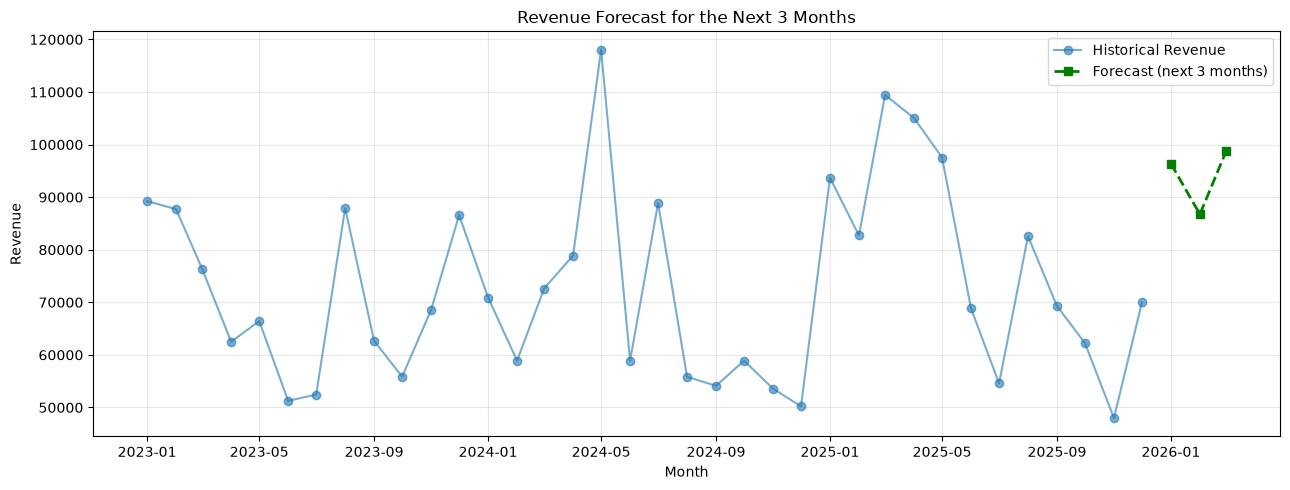

In [25]:
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing

    hw_fit = ExponentialSmoothing(
        monthly_revenue,
        trend="add",
        seasonal="mul",
        seasonal_periods=12,
        initialization_method="estimated",
    ).fit()
    forecast = hw_fit.forecast(3).round(2)
    method_used = "Holt-Winters Exponential Smoothing (additive trend + multiplicative 12-month seasonality)"
except Exception as exc:
    print(f"Holt-Winters unavailable ({exc}); falling back to a simple linear trend model.")
    slope_f, intercept_f = np.polyfit(x_idx, monthly_revenue.values, 1)
    future_steps = np.arange(len(monthly_revenue), len(monthly_revenue) + 3)
    forecast_index = pd.date_range(monthly_revenue.index[-1], periods=4, freq="MS")[1:]
    forecast = pd.Series((intercept_f + slope_f * future_steps).round(2), index=forecast_index)
    method_used = "Simple Linear Trend Model"

print(f"Forecasting method: {method_used}\n")
forecast_df = forecast.to_frame("Forecasted_Revenue")
forecast_df.index.name = "Month"
print(forecast_df)

plt.figure(figsize=(13, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o", alpha=0.6, label="Historical Revenue")
plt.plot(forecast.index, forecast.values, marker="s", linestyle="--", color="green", linewidth=2,
         label="Forecast (next 3 months)")
plt.title("Revenue Forecast for the Next 3 Months")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

- **Data cleaning:** `Customer_Age` and `Rating` were the only columns with missing entries; both were imputed with their medians.
- **EDA:** All aggregations (store totals/averages, promotion comparison, best-rated product, peak revenue month), the Revenue-by-Product visualisation, and the correlation analysis identifying the strongest numerical drivers of `Revenue` are reported above.
- **Machine learning:** A Random Forest Regressor was trained on an 80/20 split with one-hot encoded categoricals; MAE, MSE, RMSE and R2 quantify test performance, and the top-5 most important features are listed above.
- **Time series:** Monthly totals, the smoothed 3-month moving average, peak/trough months, the overall trend direction and the calendar-month seasonality profile are plotted above, and the Holt-Winters model (fallback: linear trend) forecasts the next three months of revenue.
